### Задание

Самостоятельно напишите нейронную сеть, которая может стать составной частью системы бота для игры в "Крестики-нолики". Используя подготовленную базу изображений, создайте и обучите нейронную сеть, распознающую две категории изображений: крестики и нолики. Добейтесь точности распознавания более 95% (accuracy)

In [ ]:
# Подключение класса для создания нейронной сети прямого распространения
from tensorflow.keras.models import Sequential
# Подключение класса для создания полносвязного слоя
from tensorflow.keras.layers import Dense
# Подключение оптимизатора
from tensorflow.keras.optimizers import Adam
# Подключение утилит для to_categorical
from tensorflow.keras import utils
# Подключение библиотеки для загрузки изображений
from tensorflow.keras.preprocessing import image
# Подключение библиотеки для работы с массивами
import numpy as np
# Подключение модуля для работы с файлами
import os
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
from PIL import Image
# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline

In [ ]:
# Загрузка датасета из облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_pro.zip', None, quiet=True)

'hw_pro.zip'

In [ ]:
# Распаковываем архив hw_light.zip в папку hw_light
!unzip -q hw_pro.zip

In [ ]:
# Путь к директории с базой
base_dir = '/content/hw_pro'
# Создание пустого списка для загрузки изображений обучающей выборки
x_train = []
# Создание списка для меток классов
y_train = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20
# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    # Перебор файлов в папках
    for img in os.listdir(base_dir + '/' + patch):
        # Добавление в список изображений текущей картинки
        x_train.append(image.img_to_array(image.load_img(base_dir + '/' + patch + '/' + img,
                                                         target_size=(img_height, img_width),
                                                         color_mode='grayscale')))
        # Добавление в массив меток, соответствующих классам
        if patch == '0':
            y_train.append(0)
        else:
            y_train.append(1)
# Преобразование в numpy-массив загруженных изображений и меток классов
x_train = np.array(x_train)
y_train = np.array(y_train)
# Вывод размерностей
print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)

Размер массива x_train (102, 20, 20, 1)
Размер массива y_train (102,)


In [ ]:
x_train2 = x_train.astype("float32") / 255.0 # изменение типа и нормализация значений пикселей
x_train2 = x_train2.reshape(-1, 400) # преобразование каждого изображения в вектор длиной 400

y_train2 = y_train.astype("float32")

np.random.seed(42) # фиксации случайности для одинакового перемешивания
idx = np.random.permutation(len(x_train2)) # создание массива случайно перемешанных индексов
# перемешивание обучающих данных
x_train2 = x_train2[idx]
y_train2 = y_train2[idx]

# создание модели
model = Sequential()
model.add(Dense(128, input_dim=400, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# компиляция модели
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
# обучение модели
trained = model.fit(x_train2, y_train2, epochs=18, batch_size=16, validation_split=0.25, verbose=1, shuffle=True)
model.save_weights('pro.weights.h5') # сохранение весов

# финальная точность
final_train_acc = trained.history['accuracy'][-1]

print("Финальная точность:", final_train_acc)

Epoch 1/18


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6316 - loss: 0.6739 - val_accuracy: 0.8077 - val_loss: 0.5607
Epoch 2/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8553 - loss: 0.5237 - val_accuracy: 0.9231 - val_loss: 0.4710
Epoch 3/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8816 - loss: 0.4475 - val_accuracy: 0.6538 - val_loss: 0.5621
Epoch 4/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9079 - loss: 0.3812 - val_accuracy: 0.9615 - val_loss: 0.3804
Epoch 5/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9079 - loss: 0.3382 - val_accuracy: 0.9615 - val_loss: 0.3369
Epoch 6/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.2691 - val_accuracy: 0.8462 - val_loss: 0.3851
Epoch 7/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9868 - loss: 0.1966 - val_accuracy: 1.0000 - val_loss: 0.2464
Epoch 8/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.1705 - val_accuracy: 0.8462 - val_loss: 0.3289
Epoch 9/18


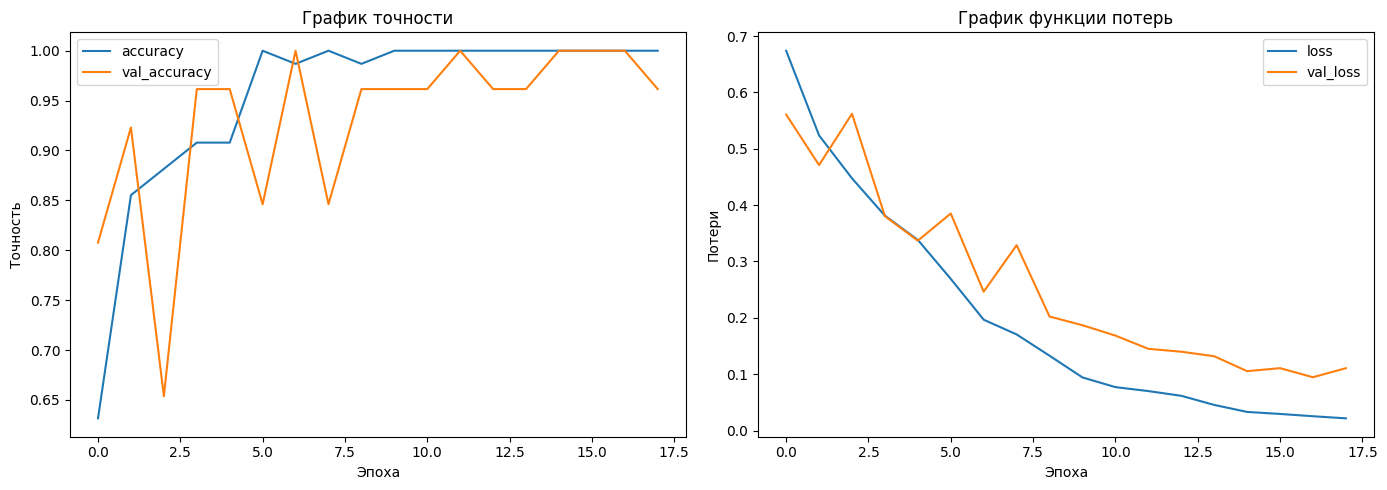

In [ ]:
# графики точности и функции потерь
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(trained.history['accuracy'], label='accuracy')
plt.plot(trained.history['val_accuracy'], label='val_accuracy')
plt.title('График точности')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(trained.history['loss'], label='loss')
plt.plot(trained.history['val_loss'], label='val_loss')
plt.title('График функции потерь')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()